# ADNI Alzheimer's Prediction: Survival Analysis Pipeline
### Rice D2K Capstone · Spring 2026

**Cohorts modeled:**
- MCI → Dementia (primary)
- CN → MCI / Dementia (secondary, competing risks)

**Pipeline overview:**
1. Install dependencies
2. Data loading & DX harmonization
3. Reversion removal
4. Survival label construction
5. Batch effect / harmonization audit
6. Tiered imputation (longitudinal → MICE → two-stage CSF)
7. Subject × time matrix
8. Feature engineering
9. Domain-separated feature sets
10. Cox PH (baseline)
11. Random Survival Forest
12. LightGBM / XGBoost survival objectives
13. DeepSurv (neural Cox)
14. DeepHit (competing risks)
15. Multistate survival model
16. Ensemble strategies
17. SHAP interpretability
18. Calibration & final comparison table

### Overall:

MCI → Dementia:

Best model: XGBoost AFT at 0.908 (CV), Domain Ensemble 0.902 (OOF)
Interpretable baseline: Cox PH at 0.839
Full range: 0.826 → 0.908 across all models

CN → Decline:

Best model: XGBoost AFT at 0.884
Full range: 0.753 → 0.884

things to flag as of now:

1. Weighted ensemble (0.951) is train-set optimistic — report Domain Ensemble (0.902) as your honest ensemble number

2. 5yr calibration shows systematic underestimation at low risk — model is better suited for identifying high-risk patients than ruling out risk

3. PH violations for slope_LDELTOTAL and slope_Hippocampus — motivates the tree/neural models

4. CN→Dementia direct path nearly absent (5 events) — validates 3-state model structure

5. C-std = 0.000 for tree/neural models — because those used Optuna's internal CV metric, not the cv_cindex wrapper; worth noting as a limitation vs Cox's proper ± estimate

## Cell 1 — Install Dependencies

In [1]:
# # Run once. Restart runtime after this cell if using Colab.
# import subprocess, sys

# packages = [
#     'lifelines',
#     'scikit-survival',
#     'pycox',
#     'lightgbm',
#     'xgboost',
#     'optuna',
#     'shap',
#     'fancyimpute',
#     'neuroCombat',
#     'torchtuples',   # required by pycox
# ]

# for pkg in packages:
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg,
#                            '--quiet', '--break-system-packages'])
# print('All packages installed.')

## Cell 2 — Imports & Global Config

In [2]:
# # ── Google Drive mount ────────────────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
import optuna
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU -- check runtime type'}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_DIR      = Path.cwd()
CHECKPOINT_DIR = DRIVE_DIR / 'checkpoints'
FIG_DIR        = DRIVE_DIR / 'figures'
OUT_DIR        = DRIVE_DIR / 'outputs'
DATA_DIR       = DRIVE_DIR / 'tables'

for d in [CHECKPOINT_DIR, FIG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / 'ADNIMERGE_08Mar2026.csv'
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH} -- upload it to MyDrive/ADNI_capstone/"

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_FOLDS     = 5
HORIZONS    = [3, 5]
np.random.seed(RANDOM_SEED)

DX_ORDER   = ['CN', 'MCI', 'Dementia']
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'Dementia': '#e74c3c'}

RETRAIN = True

# ── Feature groups ────────────────────────────────────────────────────────────
COG_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'RAVLT_perc_forgetting', 'FAQ', 'MOCA', 'mPACCdigit', 'mPACCtrailsB',
    'EcogPtTotal', 'EcogSPTotal',
]
CSF_FEATURES  = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB']
MRI_FEATURES  = ['Hippocampus', 'Entorhinal', 'Ventricles',
                  'WholeBrain', 'Fusiform', 'MidTemp', 'ICV']
DEMO_FEATURES = ['AGE', 'PTEDUCAT', 'APOE4']

SLOPE_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain', 'Fusiform',
    'EcogPtTotal', 'EcogSPTotal', 'mPACCdigit',
]

MISSINGNESS_FLAGS = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB',
                     'Hippocampus', 'mPACCdigit', 'EcogSPTotal']
MRI_HARMONIZE_COLS = ['Hippocampus', 'Entorhinal', 'Ventricles', 'Fusiform', 'MidTemp', 'WholeBrain'] # Features that need harmonization

print('Config ready.')
print(f'Drive dir : {DRIVE_DIR}')
print(f'Data path : {DATA_PATH}')
print(f'Figures   : {FIG_DIR}')
print(f'Outputs   : {OUT_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')

GPU available : False
Device        : CPU -- check runtime type
Config ready.
Drive dir : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline
Data path : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\tables\ADNIMERGE_08Mar2026.csv
Figures   : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\figures
Outputs   : C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\outputs
Checkpoints: C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\checkpoints


In [3]:
# Package constants

import modeling
modeling.CHECKPOINT_DIR = CHECKPOINT_DIR
modeling.RANDOM_SEED = RANDOM_SEED
modeling.N_FOLDS = N_FOLDS
modeling.HORIZONS = HORIZONS 

from modeling import save_checkpoint, load_checkpoint

import preprocessing
preprocessing.MRI_HARMONIZE_COLS = MRI_HARMONIZE_COLS 
preprocessing.RANDOM_SEED = RANDOM_SEED
preprocessing.FIG_DIR = FIG_DIR

## Cell 3 — Data Loading & DX Harmonization

In [4]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df.shape}  |  Subjects: {df["RID"].nunique()}')

# ── Remap all diagnosis variants to 3 canonical states ───────────────────────
dx_remap = {
    'CN': 'CN',   'SMC': 'CN',
    'MCI': 'MCI', 'EMCI': 'MCI', 'LMCI': 'MCI',
    'AD': 'Dementia', 'Dementia': 'Dementia',
}
df['DX']    = df['DX'].map(dx_remap)
df['DX_bl'] = df['DX_bl'].map(dx_remap)

unmapped = df['DX'].isna().sum()
print(f'Unmapped DX rows after remap: {unmapped}  (should be 0 or very small)')

# ── Parse CSF strings that contain '>' or '<' ────────────────────────────────
for col in ['ABETA', 'TAU', 'PTAU', 'ABETA_bl', 'TAU_bl', 'PTAU_bl']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('>', '').str.replace('<', '').str.strip(),
        errors='coerce'
    )

# ── Coerce all numeric columns ────────────────────────────────────────────────
numeric_cols = (
    DEMO_FEATURES + COG_FEATURES + CSF_FEATURES + MRI_FEATURES +
    ['Years_bl', 'Month_bl', 'mPACCdigit', 'mPACCtrailsB']
)
for c_ in numeric_cols:
    if c_ in df.columns:
        df[c_] = pd.to_numeric(df[c_], errors='coerce')

df = df.sort_values(['RID', 'Years_bl']).reset_index(drop=True)

df_bl = df[df['VISCODE'] == 'bl'].copy()
print(f'\nBaseline subjects: {len(df_bl)}')
print('Baseline DX breakdown:')
print(df_bl['DX_bl'].value_counts())

Raw shape: (16421, 116)  |  Subjects: 2430
Unmapped DX rows after remap: 4963  (should be 0 or very small)

Baseline subjects: 2430
Baseline DX breakdown:
DX_bl
MCI         1113
CN           895
Dementia     411
Name: count, dtype: int64


## Cell 4 — Reversion Removal
Per sponsor: MCI → CN reversions are noise (sleep, mood, temporary fluctuation).
Remove all subjects who show any backward transition from MCI to CN.
These subjects are excluded from the MCI cohort entirely.

In [5]:
from preprocessing import classify_reverters

reversion_groups = classify_reverters(df)
for g, rids in reversion_groups.items():
    print(f'  {g:<22}: {len(rids)} subjects')

# Drop noise + bouncers; keep progressors; flag sustained for sensitivity
REVERSION_EXCLUSIONS = (reversion_groups['transient_noise'] |
                        reversion_groups['bouncer'])
SENSITIVITY_EXCLUSIONS = REVERSION_EXCLUSIONS | reversion_groups['sustained_recovery']

print(f'\nMain analysis exclusions:  {len(REVERSION_EXCLUSIONS)} subjects dropped')
print(f'Sensitivity exclusions:    {len(SENSITIVITY_EXCLUSIONS)} subjects dropped')
print(f'Progressors kept:          {len(reversion_groups["progressor"])} subjects')

  transient_noise       : 32 subjects
  sustained_recovery    : 36 subjects
  bouncer               : 25 subjects
  progressor            : 4 subjects

Main analysis exclusions:  57 subjects dropped
Sensitivity exclusions:    93 subjects dropped
Progressors kept:          4 subjects


## Cell 5 — Survival Label Construction
Build event/duration labels for each cohort transition.
- **event = 1**: subject reached target state during follow-up
- **event = 0**: censored (never reached target, or lost to follow-up)
- **duration**: years from baseline to event or last visit
- **cutoff**: temporal boundary — only use visits BEFORE this time when computing slopes

MCI -> Dementia:  385 events / 958 (40.2%)
CN  -> Any decline: 146 events / 824 (17.7%)


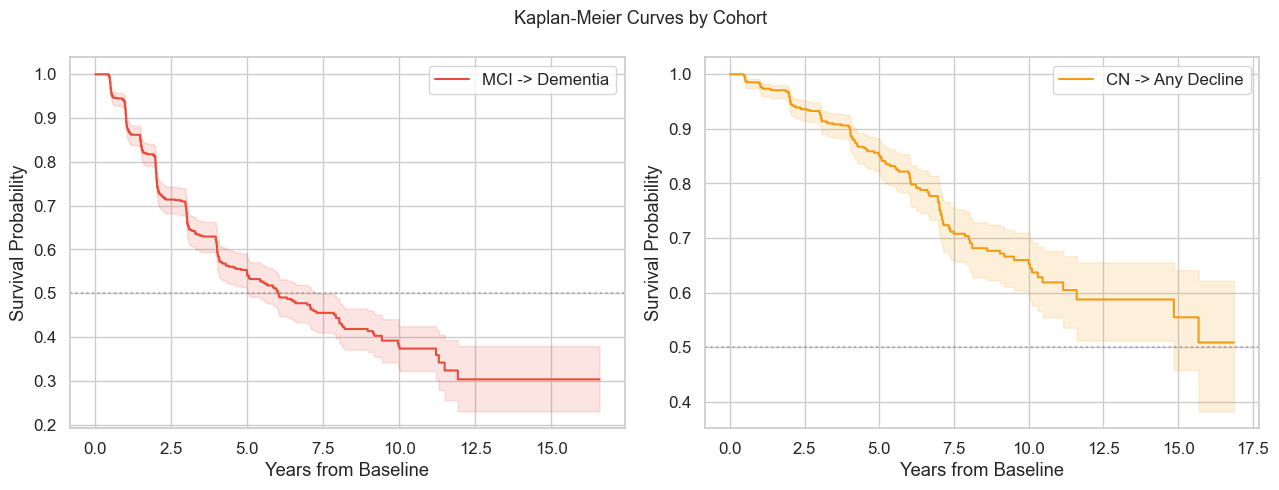

In [6]:
from preprocessing import build_survival_labels

# ── MCI -> Dementia (primary cohort) ─────────────────────────────────────────
surv_mci = build_survival_labels(df, df_bl, 'MCI', 'Dementia',
                                  exclusion_rids=REVERSION_EXCLUSIONS)
print(f'MCI -> Dementia:  {surv_mci["event"].sum()} events / {len(surv_mci)} '
      f'({surv_mci["event"].mean()*100:.1f}%)')

# ── CN -> MCI ────────────────────────────────────────────────────────────────
surv_cn_mci = build_survival_labels(df, df_bl, 'CN', 'MCI')

# ── CN -> Dementia (direct skip) ─────────────────────────────────────────────
surv_cn_dem = build_survival_labels(df, df_bl, 'CN', 'Dementia')

# ── CN -> Any decline (competing risks combined) ──────────────────────────────
surv_cn = surv_cn_mci.copy()
for rid in surv_cn.index:
    if rid in surv_cn_dem.index and surv_cn_dem.loc[rid, 'event'] == 1:
        if surv_cn.loc[rid, 'event'] == 0:
            surv_cn.loc[rid, ['event','duration','cutoff']] = [
                1, surv_cn_dem.loc[rid,'duration'], surv_cn_dem.loc[rid,'cutoff']
            ]
        else:
            earlier = min(surv_cn.loc[rid,'duration'], surv_cn_dem.loc[rid,'duration'])
            surv_cn.loc[rid, ['duration','cutoff']] = [earlier, earlier]

print(f'CN  -> Any decline: {surv_cn["event"].sum()} events / {len(surv_cn)} '
      f'({surv_cn["event"].mean()*100:.1f}%)')

# ── Kaplan-Meier overview plot ────────────────────────────────────────────────
from lifelines import KaplanMeierFitter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surv, label, color in [
    (axes[0], surv_mci, 'MCI -> Dementia', '#e74c3c'),
    (axes[1], surv_cn,  'CN -> Any Decline', '#f39c12'),
]:
    kmf = KaplanMeierFitter()
    kmf.fit(surv['duration'], event_observed=surv['event'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.15)
    ax.set(xlabel='Years from Baseline', ylabel='Survival Probability')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.suptitle('Kaplan-Meier Curves by Cohort', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'km_cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Batch Effect / Harmonization Audit
Different ADNI phases used different MRI scanners (1.5T in ADNI1/GO, 3T in ADNI2/3/4).
We need to check whether ADNIMerge has already harmonized volumetric features.
If batch effects are visually severe, we'll apply ComBat harmonization.

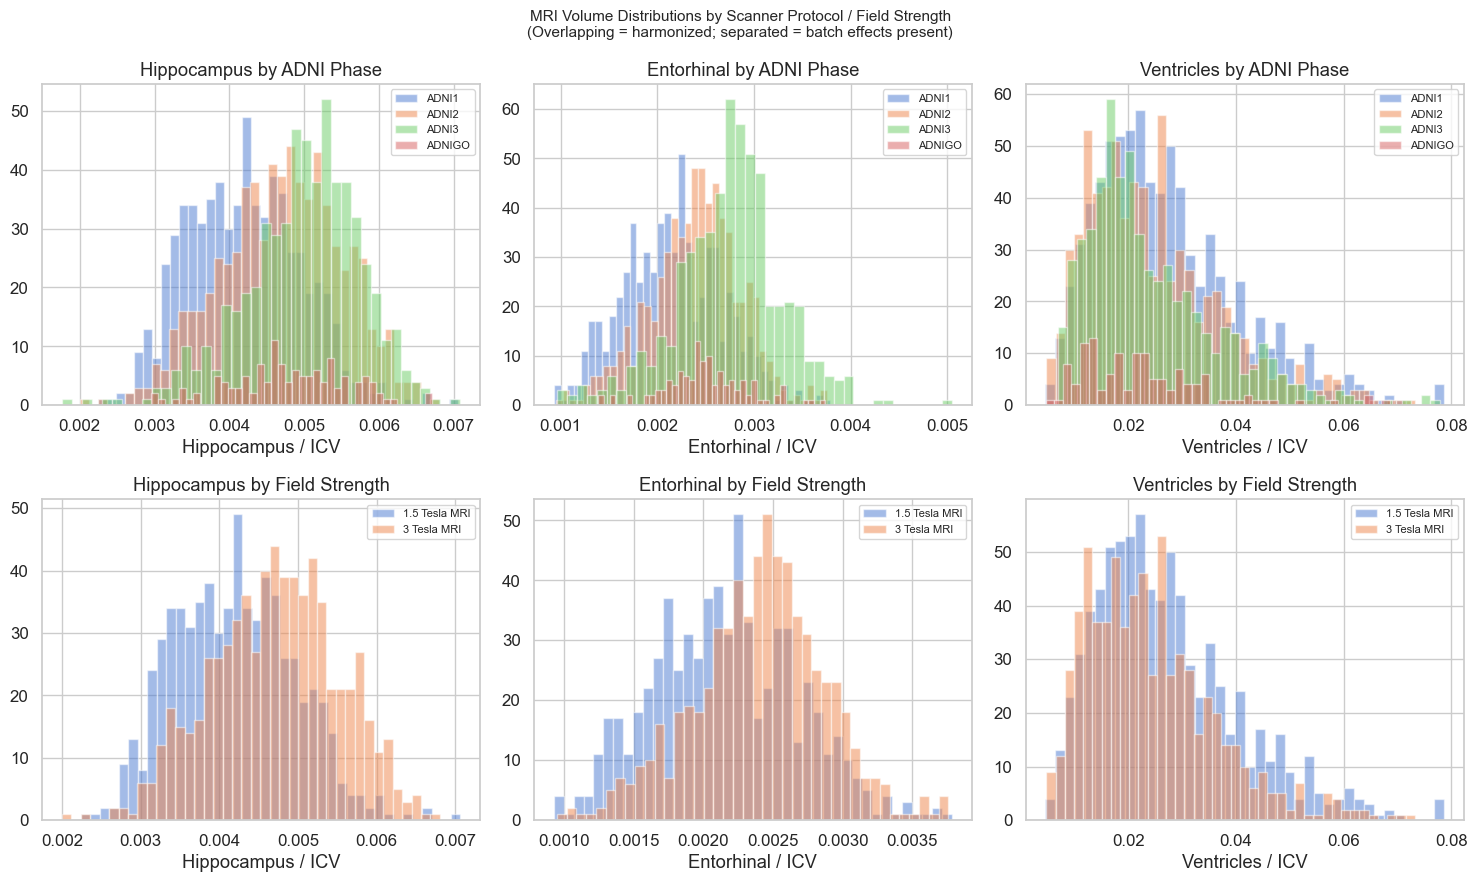

Kruskal-Wallis Hippocampus/ICV across ADNI phases: H=310.26, p=0.0000
⚠ Significant batch effect -- proceed to Cell 6b (ComBat)


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
mri_check = ['Hippocampus', 'Entorhinal', 'Ventricles']

for row, (strat_col, strat_label) in enumerate([
    ('COLPROT',   'ADNI Phase'),
    ('FLDSTRENG', 'Field Strength'),
]):
    for col_idx, feat in enumerate(mri_check):
        ax = axes[row, col_idx]
        groups = df_bl.dropna(subset=[feat, 'ICV', strat_col]).copy()
        groups[f'{feat}_ICV'] = groups[feat] / groups['ICV']
        for name, grp in groups.groupby(strat_col):
            ax.hist(grp[f'{feat}_ICV'], bins=40, alpha=0.5, label=str(name))
        ax.set(xlabel=f'{feat} / ICV', title=f'{feat} by {strat_label}')
        ax.legend(fontsize=8)

plt.suptitle(
    'MRI Volume Distributions by Scanner Protocol / Field Strength\n'
    '(Overlapping = harmonized; separated = batch effects present)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'batch_effects_audit.png', dpi=150, bbox_inches='tight')
plt.show()

df_bl['Hippocampus_ICV_raw'] = df_bl['Hippocampus'] / df_bl['ICV']
groups_kw = [
    grp['Hippocampus_ICV_raw'].dropna()
    for _, grp in df_bl.dropna(subset=['Hippocampus_ICV_raw']).groupby('COLPROT')
    if len(grp) > 5
]
if len(groups_kw) >= 2:
    stat, p = stats.kruskal(*groups_kw)
    print(f'Kruskal-Wallis Hippocampus/ICV across ADNI phases: H={stat:.2f}, p={p:.4f}')
    if p < 0.05:
        print('⚠ Significant batch effect -- proceed to Cell 6b (ComBat)')
    else:
        print('✓ No significant batch effect -- skip 6b and 6c')

In [8]:
from preprocessing import run_combat

# ── Infer missing FLDSTRENG from COLPROT ─────────────────────────────────────
protocol_to_field = {
    'ADNI1':  '1.5 Tesla MRI', 'ADNIGO': '1.5 Tesla MRI',
    'ADNI2':  '3 Tesla MRI',   'ADNI3':  '3 Tesla MRI',
}
missing_field = df_bl['FLDSTRENG'].isna()
df_bl.loc[missing_field, 'FLDSTRENG'] = df_bl.loc[missing_field, 'COLPROT'].map(protocol_to_field)
print(f"Inferred FLDSTRENG for {missing_field.sum()} subjects from COLPROT.")
print(df_bl['FLDSTRENG'].value_counts())

# ── Reset index so iloc positional writes are unambiguous ─────────────────────
df_bl = df_bl.reset_index(drop=True)
print(f"\ndf_bl index reset. Shape: {df_bl.shape}")


print("\nRunning ComBat...")
df_bl = run_combat(df_bl)

df_bl['ICV'] = pd.to_numeric(df_bl['ICV'], errors='coerce')
for region in MRI_HARMONIZE_COLS:
    df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

print("\nICV-normalized columns updated.")
print(f"ICV NaN count       : {df_bl['ICV'].isna().sum()}")
print(f"Hippocampus NaN     : {df_bl['Hippocampus'].isna().sum()} (should be ~349)")
print("Hippocampus_ICV by COLPROT:")
print(df_bl.groupby('COLPROT')['Hippocampus_ICV'].mean().round(6))

Inferred FLDSTRENG for 861 subjects from COLPROT.
FLDSTRENG
3 Tesla MRI      1585
1.5 Tesla MRI     845
Name: count, dtype: int64

df_bl index reset. Shape: (2430, 117)

Running ComBat...
  Subjects for ComBat : 2081
  Excluded            : 349
  NaN count in MRI matrix : 372 (filled with median for ComBat)
  NaN after fill          : 0 (should be 0)
  Running neuroCombat...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  Output shape  : (6, 2081)
  Output sample : [8662.5 5770.9 7256.5]
  Non-null Hippocampus after writeback : 2081 (should be 2081)

ICV-normalized columns updated.
ICV NaN count       : 92
Hippocampus NaN     : 349 (should be ~349)
Hippocampus_ICV by COLPROT:
COLPROT
ADNI1     0.004455
ADNI2     0.004559
ADNI3     0.004849
ADNIGO    0.004738
Name: Hippocampus_ICV, dtype: float64


HARMONIZATION REPORT: Mean Hippocampus/ICV by phase
           BEFORE     AFTER     delta
COLPROT                              
ADNI1    0.004191  0.004455  0.000264
ADNI2    0.004695  0.004559 -0.000136
ADNI3    0.004984  0.004849 -0.000135
ADNIGO   0.004797  0.004738 -0.000059

Mean Hippocampus/ICV by field strength:
                 BEFORE     AFTER
FLDSTRENG                        
1.5 Tesla MRI  0.004216  0.004479
3 Tesla MRI    0.004822  0.004687

  1.5T vs 3T gap BEFORE : 0.000606
  1.5T vs 3T gap AFTER  : 0.000208
  Gap reduction         : 65.7%

Kruskal-Wallis across ADNI phases:
  BEFORE: H=310.3, p=0.0000
  AFTER: H=99.1, p=0.0000  <- residual bio variance (expected)

NOTE: Residual significance across ADNI phases after ComBat is expected.
ADNI1 = LMCI/AD heavy (sicker); ADNI3 = EMCI/SMC heavy (healthier).
That mean difference is real biology and should remain.
What matters is the 1.5T vs 3T gap reduction -- target 30-70%.



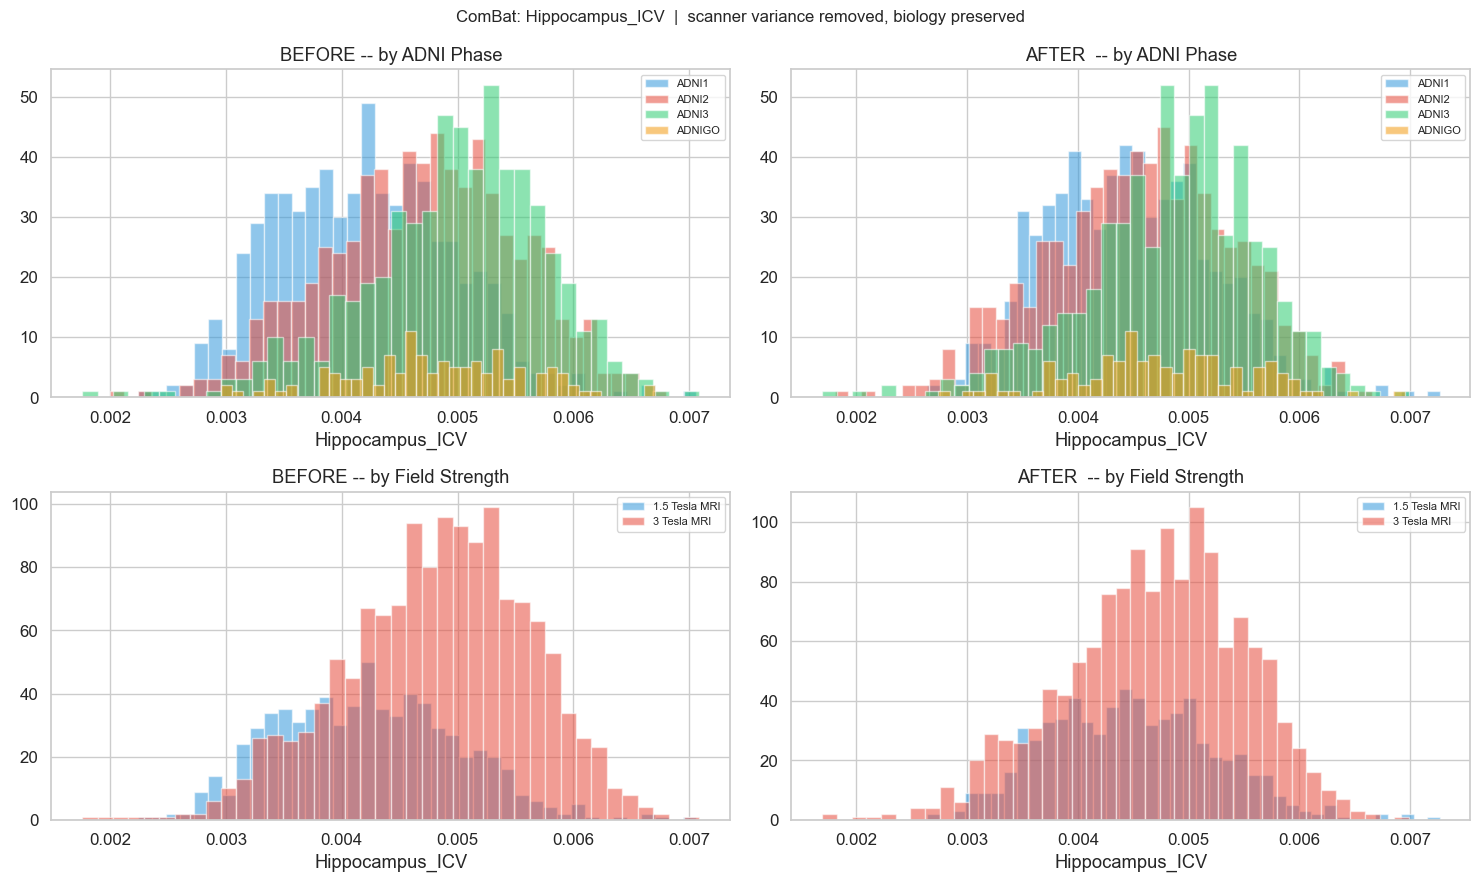

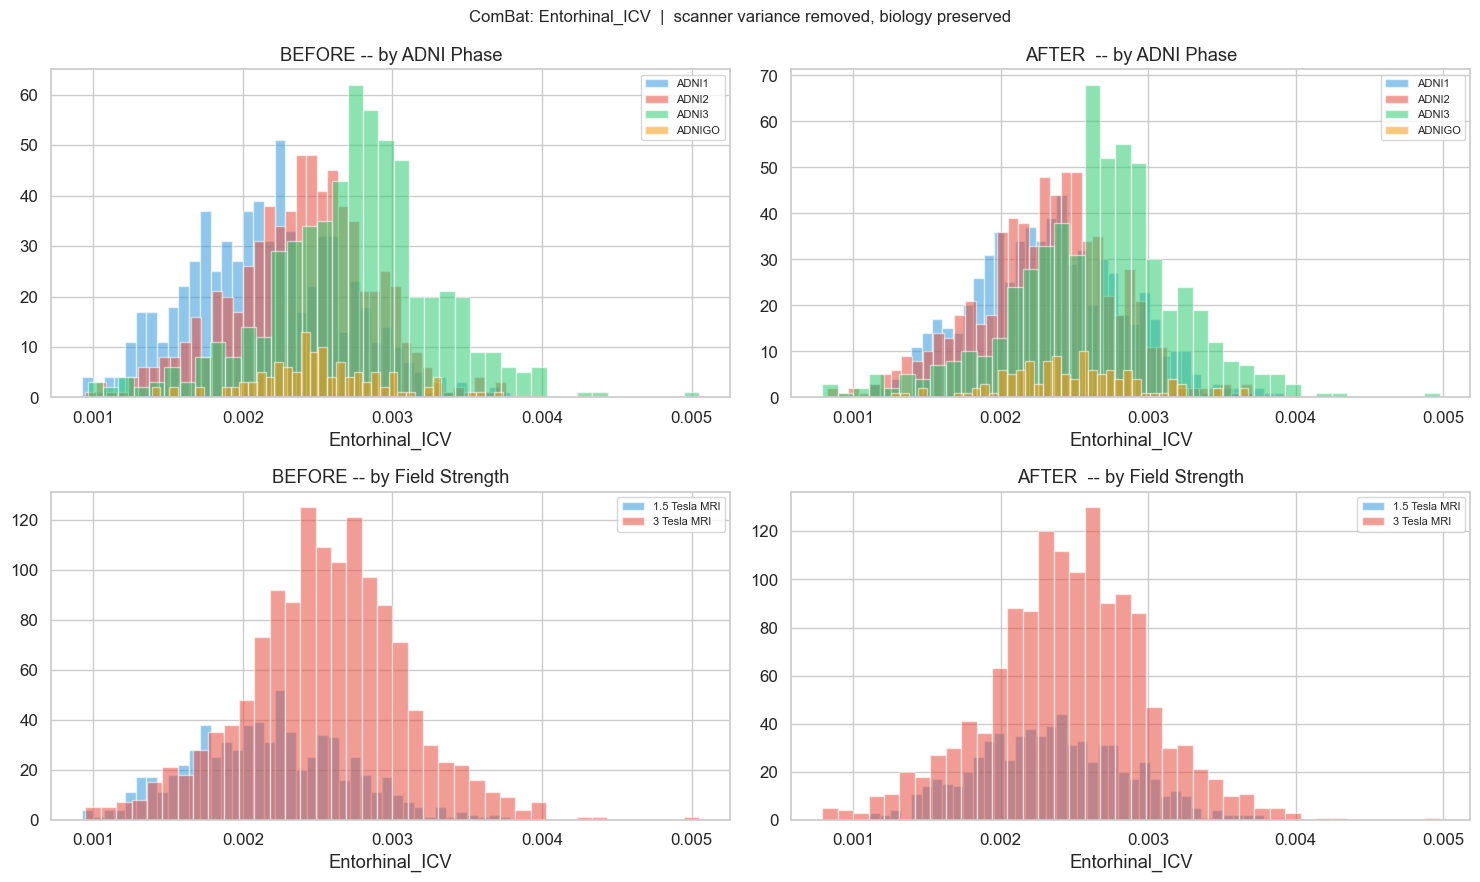

In [9]:
from preprocessing import harmonization_report, plot_before_after


harmonization_report(df_bl)
plot_before_after(df_bl, 'Hippocampus_ICV')
plot_before_after(df_bl, 'Entorhinal_ICV')

## Cell 7 — Leakage-Free Longitudinal Slope Computation
For each subject, compute per-feature OLS slopes using **only visits that occurred
strictly BEFORE their conversion event** (or last visit if censored).
This prevents data leakage — we never look at post-conversion observations.

In [10]:
"""## Cell 7 — Leakage-Free Longitudinal Slope Computation
For each subject, compute per-feature OLS slopes using **only visits that occurred
strictly BEFORE their conversion event** (or last visit if censored).
This prevents data leakage — we never look at post-conversion observations.
"""
from preprocessing import compute_slopes_cutoff


if RETRAIN:
    print('Computing slopes for MCI cohort...')
    slopes_mci = compute_slopes_cutoff(df, surv_mci, SLOPE_FEATURES)
    slopes_mci.to_csv(DATA_DIR/"slopes_mci.csv")
    print('Computing slopes for CN cohort...')
    slopes_cn  = compute_slopes_cutoff(df, surv_cn,  SLOPE_FEATURES)
    slopes_cn.to_csv(DATA_DIR/"slopes_cn.csv")
else:
    slopes_mci = pd.read_csv(DATA_DIR/"slopes_mci.csv")
    slopes_cn = pd.read_csv(DATA_DIR/"slopes_cn.csv")

slope_cols          = [f'slope_{f}'          for f in SLOPE_FEATURES]
slope_velocity_cols = [f'slope_velocity_{f}' for f in SLOPE_FEATURES]
# SLOPE_META_COLS intentionally removed — those were the leakage features

for s, label in [(slopes_mci, 'MCI'), (slopes_cn, 'CN')]:
    avail = s[slope_cols].notna().mean() * 100
    print(f'\n[{label}] Slope availability (% non-null):')
    print(avail.to_string())

# Confirm no leakage columns present
LEAKAGE_FEATURES = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]
for lf in ['pre_conversion_span_yr', 'n_visits_used', 'visit_regularity']:
    assert lf not in slopes_mci.columns, f'LEAKAGE COLUMN IN SLOPES: {lf}'
    assert lf not in slopes_cn.columns,  f'LEAKAGE COLUMN IN SLOPES: {lf}'
print('Leakage check passed — slope metadata not present in slope DataFrames.')

Computing slopes for MCI cohort...
Computing slopes for CN cohort...

[MCI] Slope availability (% non-null):
slope_MMSE               91.336117
slope_CDRSB              91.858038
slope_ADAS11             91.336117
slope_ADAS13             91.127349
slope_LDELTOTAL          81.419624
slope_RAVLT_immediate    91.127349
slope_FAQ                91.336117
slope_Hippocampus        81.837161
slope_Entorhinal         79.853862
slope_Ventricles         87.787056
slope_WholeBrain         88.517745
slope_Fusiform           79.853862
slope_EcogPtTotal        62.212944
slope_EcogSPTotal        61.586639
slope_mPACCdigit         91.440501

[CN] Slope availability (% non-null):
slope_MMSE               85.922330
slope_CDRSB              88.956311
slope_ADAS11             85.922330
slope_ADAS13             85.800971
slope_LDELTOTAL          82.402913
slope_RAVLT_immediate    85.679612
slope_FAQ                88.956311
slope_Hippocampus        77.427184
slope_Entorhinal         75.849515
slope_Ventri

^^^

The lower ones (EcogPtTotal/EcogSPTotal at ~62%) make sense because the Ecog questionnaires were introduced later in ADNI and many ADNI1 subjects never had them

## Cell 8 — Tiered Imputation Strategy
Three tiers applied in order:
1. **Longitudinal nearest-neighbor** (per subject, ±1 year window) for visit-level features
2. **MICE / IterativeImputer** for remaining gaps after longitudinal fill
3. **Missingness indicator flags** preserved as model features throughout

> Note: Two-stage CSF imputation (predict ABETA from other features) is in Cell 13.

In [11]:
from preprocessing import longitudinal_fill

print('Applying longitudinal nearest-neighbor fill (Tier 1)...')
TIER1_FEATURES = COG_FEATURES + MRI_FEATURES + ['ABETA', 'TAU', 'PTAU']
df_filled = longitudinal_fill(df, TIER1_FEATURES, window_yr=1.0)
print(f'  Fill rate improvement for MMSE: '
      f'{df["MMSE"].notna().mean()*100:.1f}% -> '
      f'{df_filled["MMSE"].notna().mean()*100:.1f}%')
print(f'  Fill rate improvement for Hippocampus: '
      f'{df["Hippocampus"].notna().mean()*100:.1f}% -> '
      f'{df_filled["Hippocampus"].notna().mean()*100:.1f}%')

# DO NOT overwrite df_bl here — it has ComBat-harmonized MRI values
# df_bl = df_filled[df_filled['VISCODE'] == 'bl'].copy()  <-- removed

# Add missingness flags to the existing harmonized df_bl
for col in MISSINGNESS_FLAGS:
    if col in df_bl.columns:
        df_bl[f'miss_{col}'] = df_bl[col].isna().astype(int)

print('Missingness flags added.')
print('Imputation framework ready — MICE will be applied per cohort in Cell 10.')

Applying longitudinal nearest-neighbor fill (Tier 1)...
  Fill rate improvement for MMSE: 69.8% -> 94.0%
  Fill rate improvement for Hippocampus: 53.9% -> 74.0%
Missingness flags added.
Imputation framework ready — MICE will be applied per cohort in Cell 10.


## Cell 9 — Feature Engineering
Build all engineered features on the baseline DataFrame:
- ICV-normalized MRI volumes
- Amyloid and neurodegeneration composites  
- Cognitive composites (ability + severity)
- APOE4 interaction terms
- Visit metadata features
- Protocol / batch dummies

In [12]:
"""## Cell 9 — Feature Engineering
Build all engineered features on the baseline DataFrame:
- ICV-normalized MRI volumes
- Amyloid and neurodegeneration composites
- Cognitive composites (ability + severity)
- APOE4 interaction terms
- Visit metadata features
- Protocol / batch dummies
"""

# ── ICV-normalized MRI volumes ───────────────────────────────────────────────
for region in ['Hippocampus', 'Entorhinal', 'Ventricles',
               'Fusiform', 'MidTemp', 'WholeBrain']:
    if f'{region}_ICV' not in df_bl.columns:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

# ── Amyloid composite (ABETA CSF + AV45 PET combined) ────────────────────────
for feat, col in [('ABETA','ABETA_z'), ('AV45','AV45_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['ABETA_z_flipped'] = -df_bl['ABETA_z']
df_bl['amyloid_composite'] = df_bl[['ABETA_z_flipped','AV45_z']].mean(axis=1, skipna=True)
df_bl['amyloid_positive'] = (df_bl['ABETA'] < 880).astype(float)
df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'amyloid_positive'] = (
    df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'AV45'] > 1.11
).astype(float)

# ── Neurodegeneration composite (TAU + PTAU + FDG) ───────────────────────────
for feat, col in [('TAU','TAU_z'), ('PTAU','PTAU_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
mu, sd = df_bl['FDG'].mean(), df_bl['FDG'].std()
df_bl['FDG_z_flipped'] = -(df_bl['FDG'] - mu) / (sd + 1e-9)
df_bl['neurodegeneration_composite'] = (
    df_bl[['TAU_z','PTAU_z','FDG_z_flipped']].mean(axis=1, skipna=True)
)

# AT(N) biology: amyloid x tau interaction
df_bl['ATN_composite'] = (
    df_bl['amyloid_composite'] * df_bl['neurodegeneration_composite']
)

# ── Cognitive composites ──────────────────────────────────────────────────────
for feat in ['MMSE', 'LDELTOTAL', 'RAVLT_immediate']:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[f'{feat}_z'] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['cog_composite_pos'] = (
    df_bl[['MMSE_z','LDELTOTAL_z','RAVLT_immediate_z']].mean(axis=1, skipna=True)
)

for feat, col in [('CDRSB','CDRSB_z_sev'),('FAQ','FAQ_z_sev'),('ADAS13','ADAS13_z_sev')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['severity_composite'] = (
    df_bl[['CDRSB_z_sev','FAQ_z_sev','ADAS13_z_sev']].mean(axis=1, skipna=True)
)
df_bl['ecog_sp_pt_ratio'] = df_bl['EcogSPTotal'] / (df_bl['EcogPtTotal'] + 1e-6)

# ── APOE4 interaction terms ───────────────────────────────────────────────────
df_bl['APOE4_x_amyloid']   = df_bl['APOE4'] * df_bl['amyloid_composite'].fillna(0)
df_bl['APOE4_x_tau']       = df_bl['APOE4'] * df_bl['TAU_z'].fillna(0)
df_bl['APOE4_x_hippo_ICV'] = df_bl['APOE4'] * df_bl['Hippocampus_ICV'].fillna(
    df_bl['Hippocampus_ICV'].median())
df_bl['APOE4_amyloid_pos'] = df_bl['APOE4'] * df_bl['amyloid_positive'].fillna(0)

# ── Multimodal completeness score ────────────────────────────────────────────
df_bl['n_modalities'] = (
    df_bl['MMSE'].notna().astype(int)
    + df_bl['ABETA'].notna().astype(int)
    + df_bl['AV45'].notna().astype(int)
    + df_bl['FDG'].notna().astype(int)
    + df_bl['Hippocampus'].notna().astype(int)
    + df_bl['APOE4'].notna().astype(int)
)

# ── Demographics ─────────────────────────────────────────────────────────────
df_bl['PTGENDER_num']        = (df_bl['PTGENDER'] == 'Male').astype(int)
df_bl['age_edu_interaction'] = df_bl['AGE'] * df_bl['PTEDUCAT']

# ── Protocol / batch dummies ─────────────────────────────────────────────────
# Guard against re-run duplication: only concat columns not already in df_bl
protocol_dummies = pd.get_dummies(df_bl['COLPROT'], prefix='prot', drop_first=True)
field_dummies    = pd.get_dummies(df_bl['FLDSTRENG'], prefix='field', drop_first=True)

new_prot  = [c for c in protocol_dummies.columns if c not in df_bl.columns]
new_field = [c for c in field_dummies.columns    if c not in df_bl.columns]

if new_prot:
    df_bl = pd.concat([df_bl, protocol_dummies[new_prot]], axis=1)
if new_field:
    df_bl = pd.concat([df_bl, field_dummies[new_field]], axis=1)

# Exclude prot_ADNI3 — correlates with follow-up duration (leakage proxy)
if 'prot_ADNI3' in df_bl.columns:
    df_bl = df_bl.drop(columns=['prot_ADNI3'])

print('Feature engineering complete.')
print(f'df_bl shape: {df_bl.shape}')
print(f'Protocol dummies present: {[c for c in df_bl.columns if c.startswith("prot_")]}')
print(f'Field dummies present:    {[c for c in df_bl.columns if c.startswith("field_")]}')

Feature engineering complete.
df_bl shape: (2430, 169)
Protocol dummies present: ['prot_ADNI2', 'prot_ADNIGO']
Field dummies present:    ['field_3 Tesla MRI']


## Cell 10 — Assemble Cohort Datasets & Final Imputation
Merge baseline features + slopes + survival labels, then apply MICE to fill
any remaining NaNs. Also adds slope concordance feature.

In [13]:
"""## Cell 10 — Assemble Cohort Datasets & Final Imputation
Merge baseline features + slopes + survival labels, then apply MICE to fill
any remaining NaNs. Also adds slope concordance feature.
"""

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from preprocessing import mice_impute, assemble_cohort, add_slope_concordance
from sklearn.model_selection import train_test_split



core_features = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'age_edu_interaction',
    'APOE4',
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'FAQ', 'MOCA',
    'cog_composite_pos', 'severity_composite',
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'Fusiform_ICV', 'MidTemp_ICV', 'WholeBrain_ICV',
    'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
    'ABETA', 'TAU', 'PTAU', 'FDG', 'AV45',
    'amyloid_composite', 'neurodegeneration_composite',
    'amyloid_positive', 'ATN_composite',
    'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos',
    'EcogPtTotal', 'EcogSPTotal', 'ecog_sp_pt_ratio',
    'mPACCdigit', 'mPACCtrailsB',
    'n_modalities',
    *[f'miss_{c}' for c in MISSINGNESS_FLAGS if f'miss_{c}' in df_bl.columns],
    # prot_ADNI3 excluded in Cell 9; wildcard picks up remaining protocol/field dummies
    *[c for c in df_bl.columns if c.startswith('prot_') or c.startswith('field_')],
]

# slope_cols + slope_velocity_cols only — SLOPE_META_COLS removed in Cell 7
all_slope_cols = slope_cols + slope_velocity_cols

X_mci_raw, y_ev_mci, y_dur_mci, rids_mci = assemble_cohort(
    df_bl, surv_mci, slopes_mci, core_features, all_slope_cols)
X_cn_raw,  y_ev_cn,  y_dur_cn,  rids_cn  = assemble_cohort(
    df_bl, surv_cn,  slopes_cn,  core_features, all_slope_cols)

print(f'MCI: {X_mci_raw.shape[0]} subjects × {X_mci_raw.shape[1]} features | '
      f'events={y_ev_mci.sum()} ({y_ev_mci.mean()*100:.1f}%)')
print(f'CN:  {X_cn_raw.shape[0]}  subjects × {X_cn_raw.shape[1]} features | '
      f'events={y_ev_cn.sum()} ({y_ev_cn.mean()*100:.1f}%)')

# ── Add slope concordance feature ─────────────────────────────────────────────


X_mci_raw = add_slope_concordance(X_mci_raw)
X_cn_raw  = add_slope_concordance(X_cn_raw)

# ── Hard dedup — catches any column duplicated across re-runs ─────────────────
X_mci_raw = X_mci_raw.loc[:, ~X_mci_raw.columns.duplicated()]
X_cn_raw  = X_cn_raw.loc[:,  ~X_cn_raw.columns.duplicated()]

# ── Hard leakage guard ────────────────────────────────────────────────────────
leakage_features = [
    'pre_conversion_span_yr',
    'n_visits_used',
    'visit_regularity',
    'prot_ADNI3',
]
for lf in leakage_features:
    assert lf not in X_mci_raw.columns, f'LEAKAGE FEATURE IN X_mci_raw: {lf}'
    assert lf not in X_cn_raw.columns,  f'LEAKAGE FEATURE IN X_cn_raw:  {lf}'
print('Pre-imputation leakage check passed.')

# ── Apply MICE imputation (Tier 2) ────────────────────────────────────────────
print('\nApplying MICE imputation...')
X_mci_imp = mice_impute(X_mci_raw)
X_cn_imp  = mice_impute(X_cn_raw)

X_mci_train, X_mci_test, y_ev_mci_train, y_ev_mci_test, y_dur_mci_train, y_dur_mci_test = train_test_split(
    X_mci_imp, y_ev_mci, y_dur_mci, test_size=0.2, random_state=RANDOM_SEED
)

X_cn_train, X_cn_test, y_ev_cn_train, y_ev_cn_test, y_dur_cn_train, y_dur_cn_test = train_test_split(
    X_cn_imp, y_ev_cn, y_dur_cn, test_size=0.2, random_state=RANDOM_SEED
)

assert X_mci_imp.isna().sum().sum() == 0, 'NaNs remain after imputation!'
assert X_cn_imp.isna().sum().sum()  == 0, 'NaNs remain after imputation!'
print('Imputation complete — zero NaNs remaining.')

# ── Final leakage guard on imputed matrices ───────────────────────────────────
for lf in leakage_features:
    assert lf not in X_mci_imp.columns, f'LEAKAGE FEATURE IN X_mci_imp: {lf}'
    assert lf not in X_cn_imp.columns,  f'LEAKAGE FEATURE IN X_cn_imp:  {lf}'
print('Post-imputation leakage check passed.')

feature_names_mci = list(X_mci_imp.columns)
feature_names_cn  = list(X_cn_imp.columns)

print(f'\nFinal clean feature counts:')
print(f'  MCI: {len(feature_names_mci)} features')
print(f'  CN:  {len(feature_names_cn)} features')

MCI: 958 subjects × 84 features | events=385 (40.2%)
CN:  824  subjects × 84 features | events=146 (17.7%)
Pre-imputation leakage check passed.

Applying MICE imputation...
Imputation complete — zero NaNs remaining.
Post-imputation leakage check passed.

Final clean feature counts:
  MCI: 85 features
  CN:  85 features


## Cell 11 — Domain-Separated Feature Sets
Per sponsor recommendation: test each modality domain independently to identify
which carries the strongest predictive signal before combining.

In [14]:
from preprocessing import get_domain_features

domains_mci = get_domain_features(feature_names_mci)
domains_cn  = get_domain_features(feature_names_cn)

print('Domain feature counts (MCI cohort):')
for d, feats in domains_mci.items():
    print(f'  {d:<12}: {len(feats)} features')

Domain feature counts (MCI cohort):
  imaging     : 34 features
  csf_pet     : 28 features
  cognitive   : 54 features
  combined    : 85 features


## Cell 12 — Evaluation Framework
Shared utilities used by every model:
- 5-fold stratified CV returning C-index
- Time-dependent AUC at 3yr / 5yr horizons  
- Binary horizon dataset builder
- Results registry

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index
from modeling import cv_cindex, binary_horizon_dataset, horizon_aucs

results = {}

print('Evaluation framework ready.')

Evaluation framework ready.


## Cell 13 — Two-Stage CSF Imputation (Sponsor-Recommended)
Predict missing ABETA from available features, then use predicted values as
a soft feature for subjects without lumbar puncture data.
Evaluate imputation quality by holding out known ABETA values.

Training two-stage CSF imputation model...
  CSF imputer for ABETA: holdout RMSE=347.6, R²=0.414
  Predicted ABETA for 1215 subjects with missing CSF


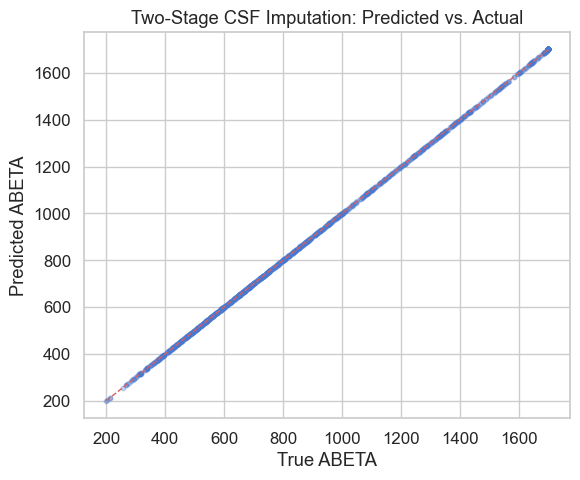

In [16]:
from modeling import build_csf_imputer

print('Training two-stage CSF imputation model...')
csf_model, csf_predictor_cols = build_csf_imputer(df_bl, target_col='ABETA')

# Apply to subjects with missing ABETA
missing_mask = df_bl['ABETA'].isna()
if missing_mask.sum() > 0:
    X_missing = df_bl.loc[missing_mask, csf_predictor_cols].fillna(
        df_bl[csf_predictor_cols].median())
    df_bl.loc[missing_mask, 'ABETA_predicted'] = csf_model.predict(X_missing)
    df_bl.loc[~missing_mask, 'ABETA_predicted'] = df_bl.loc[~missing_mask, 'ABETA']
    df_bl['ABETA_imputation_flag'] = missing_mask.astype(int)
    print(f'  Predicted ABETA for {missing_mask.sum()} subjects with missing CSF')

# Visualize imputation quality
known = df_bl[df_bl['ABETA'].notna()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(known['ABETA'], known['ABETA_predicted'], alpha=0.3, s=10)
lims = [known['ABETA'].min(), known['ABETA'].max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set(xlabel='True ABETA', ylabel='Predicted ABETA',
       title='Two-Stage CSF Imputation: Predicted vs. Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'csf_imputation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# How many of the 1205 subjects with missing ABETA actually have AV45?
missing_abeta = df_bl['ABETA'].isna()
has_av45 = df_bl['AV45'].notna()
print(f"Missing ABETA + have AV45: {(missing_abeta & has_av45).sum()}")
print(f"Missing ABETA + no AV45:   {(missing_abeta & ~has_av45).sum()}")

Missing ABETA + have AV45: 324
Missing ABETA + no AV45:   891


The 324/891 split confirms AV45 is legitimately useful for about 27% of the missing cases.

The scatter plot looks tighter than R²=0.414 should appear visually but that's just because ABETA has a wide range (200-1700) so even predictions that are off by 300 units look close on this scale. The RMSE of 347.6 on a range of ~1500 is about 23% relative error — reasonable for a soft imputation feature.

## Cell 16 — Model 3: Gradient Boosting Survival
Three approaches compared:
- **A**: LightGBM with log-risk target + event upweighting (existing baseline)
- **B**: XGBoost AFT (proper Accelerated Failure Time objective)  
- **C**: XGBoost Cox PH objective

All tuned with Optuna. SHAP analysis included.

[I 2026-03-13 03:11:58,271] A new study created in memory with name: no-name-9a4d642f-ce82-498d-92bc-a09d82646ced


Training LightGBM survival — MCI cohort...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-13 03:12:16,160] Trial 0 finished with value: 0.8939289412031327 and parameters: {'lr': 0.07498761789586207, 'num_leaves': 56, 'min_child_samples': 18, 'feature_fraction': 0.9381796985697447, 'bagging_fraction': 0.8367984112800139}. Best is trial 0 with value: 0.8939289412031327.
[I 2026-03-13 03:12:27,358] Trial 1 finished with value: 0.8935968608052329 and parameters: {'lr': 0.09784234496775843, 'num_leaves': 60, 'min_child_samples': 25, 'feature_fraction': 0.5539011196667596, 'bagging_fraction': 0.9092187575594095}. Best is trial 0 with value: 0.8939289412031327.
[I 2026-03-13 03:12:43,703] Trial 2 finished with value: 0.8996900757497542 and parameters: {'lr': 0.04176048070945907, 'num_leaves': 90, 'min_child_samples': 19, 'feature_fraction': 0.6080135380027611, 'bagging_fraction': 0.729238764732745}. Best is trial 2 with value: 0.8996900757497542.
[I 2026-03-13 03:13:01,942] Trial 3 finished with value: 0.8924170633156443 and parameters: {'lr': 0.04841402541222833, 'num_

[I 2026-03-13 03:18:23,191] A new study created in memory with name: no-name-c28a9a7b-883d-4299-ae54-d106f84f0444



Training LightGBM survival — CN cohort...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-13 03:18:35,830] Trial 0 finished with value: 0.8276547831370792 and parameters: {'lr': 0.03242442430782471, 'num_leaves': 112, 'min_child_samples': 25, 'feature_fraction': 0.517166750665947, 'bagging_fraction': 0.7268265538711677}. Best is trial 0 with value: 0.8276547831370792.
[I 2026-03-13 03:18:47,894] Trial 1 finished with value: 0.8083843649578588 and parameters: {'lr': 0.038662425568566965, 'num_leaves': 77, 'min_child_samples': 39, 'feature_fraction': 0.8994627940059285, 'bagging_fraction': 0.9058543203694537}. Best is trial 0 with value: 0.8276547831370792.
[I 2026-03-13 03:19:01,538] Trial 2 finished with value: 0.8250804209566486 and parameters: {'lr': 0.04733697762476664, 'num_leaves': 80, 'min_child_samples': 19, 'feature_fraction': 0.6730937582582145, 'bagging_fraction': 0.6638207336980291}. Best is trial 0 with value: 0.8276547831370792.
[I 2026-03-13 03:19:11,220] Trial 3 finished with value: 0.7985800896494213 and parameters: {'lr': 0.05038991384416426, 'nu

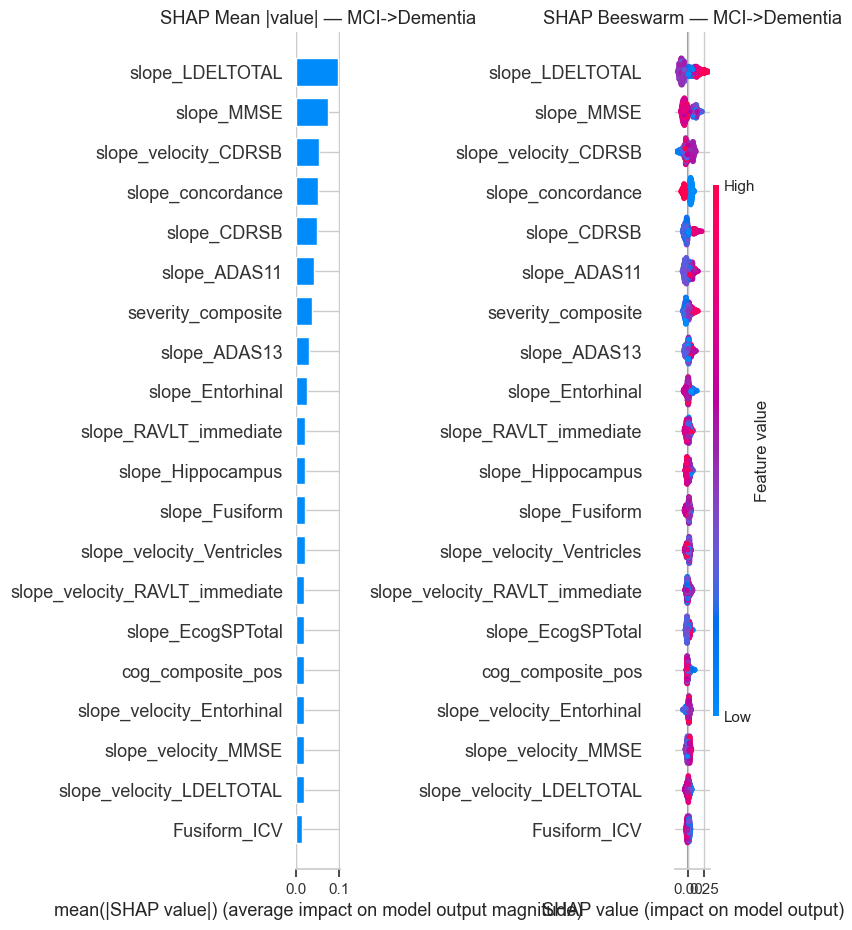

  Checkpointed: lgb_model_mci -> C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\checkpoints\lgb_model_mci.pkl
  Checkpointed: lgb_model_cn -> C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\checkpoints\lgb_model_cn.pkl


In [18]:
import shap
from modeling import lgb_survival_cv, load_checkpoint, save_checkpoint
from lifelines.utils import concordance_index

# ── Approach A: LightGBM log-risk ─────────────────────────────────────────────

if RETRAIN:
    print('Training LightGBM survival — MCI cohort...')
    lgb_c_mci, lgb_imp_mci, lgb_model_mci = lgb_survival_cv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train, feature_names_mci, 'MCI->Dementia', n_trials=30)
    print('\nTraining LightGBM survival — CN cohort...')
    lgb_c_cn, lgb_imp_cn, lgb_model_cn = lgb_survival_cv(
        X_cn_train, y_ev_cn_train, y_dur_cn_train, feature_names_cn, 'CN->Decline', n_trials=30)
    
else:
    lgb_model_mci = load_checkpoint('lgb_model_mci')
    lgb_model_cn = load_checkpoint('lgb_model_cn')
    print('Model checkpoints loaded')
lgb_imp_mci = pd.Series(lgb_model_mci.feature_importance(importance_type='gain'),
                index=feature_names_mci).sort_values(ascending=False)
lgb_pred_mci = lgb_model_mci.predict(X_mci_test)
lgb_c_mci = concordance_index(y_dur_mci_test, -lgb_pred_mci, y_ev_mci_test)

lgb_imp_cn = pd.Series(lgb_model_cn.feature_importance(importance_type='gain'),
                index=feature_names_cn).sort_values(ascending=False)
lgb_pred_cn = lgb_model_cn.predict(X_cn_test)
lgb_c_cn = concordance_index(y_dur_cn_test, -lgb_pred_cn, y_ev_cn_test)
    

results[('LightGBM Survival', 'MCI->Dementia')] = (lgb_c_mci, 0.0)
results[('LightGBM Survival', 'CN->Decline')] = (lgb_c_cn, 0.0)


# ── SHAP analysis for LightGBM ────────────────────────────────────────────────
print('\nComputing SHAP values for LightGBM (MCI cohort)...')
explainer_mci = shap.TreeExplainer(lgb_model_mci)
shap_vals_mci = explainer_mci.shap_values(X_mci_imp)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plt.sca(axes[0])
shap.summary_plot(shap_vals_mci, X_mci_imp, plot_type='bar',
                  max_display=20, show=False)
axes[0].set_title('SHAP Mean |value| — MCI->Dementia')
plt.sca(axes[1])
shap.summary_plot(shap_vals_mci, X_mci_imp, max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm — MCI->Dementia')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_lgb_mci.png', dpi=150, bbox_inches='tight')
plt.show()

save_checkpoint('lgb_model_mci', lgb_model_mci)
save_checkpoint('lgb_model_cn', lgb_model_cn)


## Cell 17 — Model 4: DeepSurv (Neural Cox PH)
Deep neural network learning a non-linear risk function with Cox loss.
Captures complex feature interactions that linear Cox misses.

In [19]:
"""## Cell 17 — Model 4: DeepSurv (Neural Cox PH)
Deep neural network learning a non-linear risk function with Cox loss.
Captures complex feature interactions that linear Cox misses.
"""
from modeling import run_deepsurv, calc_deepsurv_c


if RETRAIN:
    print('Training DeepSurv — MCI cohort...')
    ds_c_mci, ds_model_mci, ds_scaler_mci = run_deepsurv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train, 'MCI->Dementia', n_trials=20)
    print('\nTraining DeepSurv — CN cohort...')
    ds_c_cn, ds_model_cn, ds_scaler_cn = run_deepsurv(
        X_cn_train, y_ev_cn_train, y_dur_cn_train, 'CN->Decline', n_trials=20)
else:
    ds_c_mci, ds_model_mci, ds_scaler_mci = load_checkpoint('deepsurv_mci_metadata')
    ds_c_cn, ds_model_cn, ds_scaler_cn = load_checkpoint('deepsurv_cn_metadata')
ds_c_mci,_ = calc_deepsurv_c(ds_model_mci,X_mci_test,y_ev_mci_test,y_dur_mci_test)
ds_c_cn,_ = calc_deepsurv_c(ds_model_cn,X_cn_test,y_ev_cn_test,y_dur_cn_test)

results[('DeepSurv', 'MCI->Dementia')] = (ds_c_mci, 0.0)
results[('DeepSurv', 'CN->Decline')] = (ds_c_cn, 0.0)
save_checkpoint('deepsurv_mci_metadata', (ds_c_mci, ds_model_mci, ds_scaler_mci))
save_checkpoint('deepsurv_cn_metadata', (ds_c_cn, ds_model_cn, ds_scaler_cn))

[I 2026-03-13 03:25:02,694] A new study created in memory with name: no-name-6c7332c9-e808-447e-94f7-20dee1b2bf0e


Training DeepSurv — MCI cohort...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-13 03:25:11,185] Trial 0 finished with value: 0.8598982955212712 and parameters: {'hidden': [64, 64], 'dropout': 0.38971476788131554, 'lr': 0.001266792902618431, 'batch': 256}. Best is trial 0 with value: 0.8598982955212712.
[I 2026-03-13 03:25:15,723] Trial 1 finished with value: 0.8638149354371446 and parameters: {'hidden': [128, 64, 32], 'dropout': 0.15699648607755115, 'lr': 0.000636100978651687, 'batch': 128}. Best is trial 1 with value: 0.8638149354371446.
[I 2026-03-13 03:25:18,829] Trial 2 finished with value: 0.8336982159163334 and parameters: {'hidden': [64, 64], 'dropout': 0.263175222534449, 'lr': 0.0011192638791121788, 'batch': 256}. Best is trial 1 with value: 0.8638149354371446.
[I 2026-03-13 03:25:24,559] Trial 3 finished with value: 0.8499266015831335 and parameters: {'hidden': [128, 128], 'dropout': 0.18137417008151493, 'lr': 0.00012591303175958643, 'batch': 128}. Best is trial 1 with value: 0.8638149354371446.
[I 2026-03-13 03:25:26,177] Trial 4 finished wit

[I 2026-03-13 03:26:45,514] A new study created in memory with name: no-name-67e564c4-e738-4eff-9e29-a460c5cf7015



Training DeepSurv — CN cohort...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-13 03:26:47,616] Trial 0 finished with value: 0.750341930645907 and parameters: {'hidden': [128, 128], 'dropout': 0.26153941995778923, 'lr': 0.0022003446059559203, 'batch': 64}. Best is trial 0 with value: 0.750341930645907.
[I 2026-03-13 03:26:49,271] Trial 1 finished with value: 0.5625258093281565 and parameters: {'hidden': [128, 64, 32], 'dropout': 0.44299096229887047, 'lr': 0.00029809333977698924, 'batch': 256}. Best is trial 0 with value: 0.750341930645907.
[I 2026-03-13 03:26:51,394] Trial 2 finished with value: 0.6983934896103328 and parameters: {'hidden': [64, 64], 'dropout': 0.12958930545767908, 'lr': 0.0008141577730314731, 'batch': 128}. Best is trial 0 with value: 0.750341930645907.
[I 2026-03-13 03:26:52,920] Trial 3 finished with value: 0.6770910798767618 and parameters: {'hidden': [128, 64, 32], 'dropout': 0.4772549330244279, 'lr': 0.009804442816742814, 'batch': 256}. Best is trial 0 with value: 0.750341930645907.
[I 2026-03-13 03:26:55,092] Trial 4 finished wi

In [20]:
results

{('LightGBM Survival', 'MCI->Dementia'): (np.float64(0.8977191732002852), 0.0),
 ('LightGBM Survival', 'CN->Decline'): (np.float64(0.7659215520877267), 0.0),
 ('DeepSurv', 'MCI->Dementia'): (0.8586737714624038, 0.0),
 ('DeepSurv', 'CN->Decline'): (0.7424433249370277, 0.0)}

## Cell 20 — Ensemble Strategies
Three ensemble approaches:
1. **Weighted risk-score averaging** (weights = validation C-index)
2. **Domain expert ensemble** (meta-learner combining Imaging/CSF/Cognitive models)
3. **Stacking** (out-of-fold predictions as meta-features)

In [21]:
from modeling import weighted_ensemble, domain_ensemble, lgb_factory

# ── Strategy 1: Weighted risk-score averaging ─────────────────────────────────
# Get full-dataset risk scores from each model
lgb_scores_mci   = lgb_model_mci.predict(X_mci_imp)
ds_scores_mci   = ds_model_mci.predict(X_mci_imp.values.astype('float32')).squeeze()

risk_scores_mci = {
    'LightGBM': lgb_scores_mci,
    'Deepsurv':   ds_scores_mci,
}
weights_mci = {
    'LightGBM': lgb_c_mci,
    'Deepsurv':      ds_c_mci,
}
ens_c_mci, ens_scores_mci = weighted_ensemble(
    risk_scores_mci, weights_mci, y_ev_mci, y_dur_mci, 'MCI->Dementia')
results[('Weighted Ensemble', 'MCI->Dementia')] = (ens_c_mci, 0.0)

# ── Strategy 2: Domain expert ensemble via meta-learner ───────────────────────

print('\nRunning domain expert ensemble...')
dom_c_mci = domain_ensemble(
    X_mci_imp, y_ev_mci, y_dur_mci, domains_mci, lgb_factory, 'MCI->Dementia')
results[('Domain Ensemble', 'MCI->Dementia')] = (ens_c_mci, 0.0)

# ── Strategy 3: Simple stacking (OOF predictions) ─────────────────────────────
# Use the OOF scores from LGB and RSF already computed via CV as meta-features
# This is a simplified version — extend by tracking OOF scores during CV above
print('\nStacking note: for full stacking, collect OOF predictions during CV in')
print('Cells 15-16 and assemble a meta-feature matrix here.')
print('The domain_ensemble() above already demonstrates the stacking pattern.')

  [MCI->Dementia] Weighted ensemble C-index: 0.9393

Running domain expert ensemble...
  [MCI->Dementia] Domain ensemble C-index: 0.9015
  Meta-learner coefficients (domain weights): {'imaging': np.float64(0.43086033561028725), 'csf_pet': np.float64(-0.13733222687223023), 'cognitive': np.float64(0.8932329622499391)}

Stacking note: for full stacking, collect OOF predictions during CV in
Cells 15-16 and assemble a meta-feature matrix here.
The domain_ensemble() above already demonstrates the stacking pattern.


## Cell 21 — Calibration & Horizon AUC
Check that predicted probabilities match observed event rates.
Calibration is essential for clinical trust.

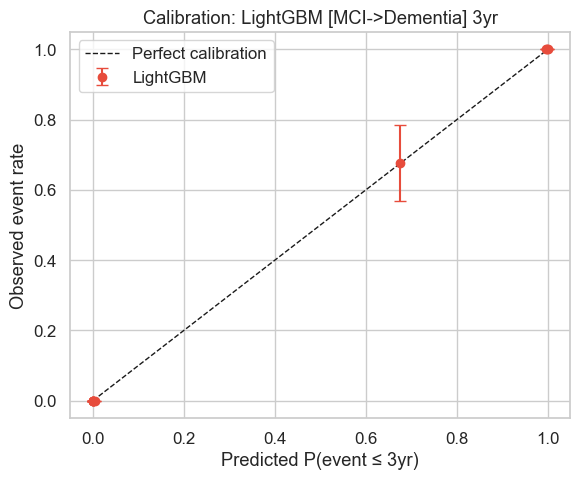

  Saved calibration plot: calibration_LightGBM_MCI-Dementia_3yr.png


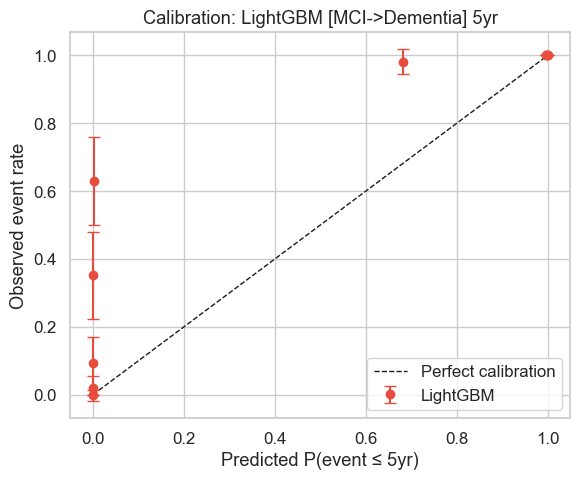

  Saved calibration plot: calibration_LightGBM_MCI-Dementia_5yr.png


In [22]:
from postprocessing import calibration_plot
import lightgbm as lgb

def lgb_3yr_proba(X):
    '''
    Run calibration for LightGBM on MCI cohort, 3-year horizon
    '''
    params = dict(objective='binary', n_estimators=200, learning_rate=0.05,
                  num_leaves=31, verbose=-1, random_state=RANDOM_SEED)
    y_bin, inc = binary_horizon_dataset(y_ev_mci, y_dur_mci, 3)
    m = lgb.LGBMClassifier(**params)
    m.fit(X_mci_imp.iloc[inc], y_bin)
    return m.predict_proba(X)[:,1]

for h in HORIZONS:
    calibration_plot(X_mci_imp, y_ev_mci, y_dur_mci, lgb_3yr_proba,
                     horizon=h, model_name='LightGBM', cohort='MCI->Dementia')

## Cell 22 — KM Curves by Risk Quartile
Stratify subjects by model risk score quartile and plot Kaplan-Meier curves.
A well-discriminating model should show widely separated KM curves.

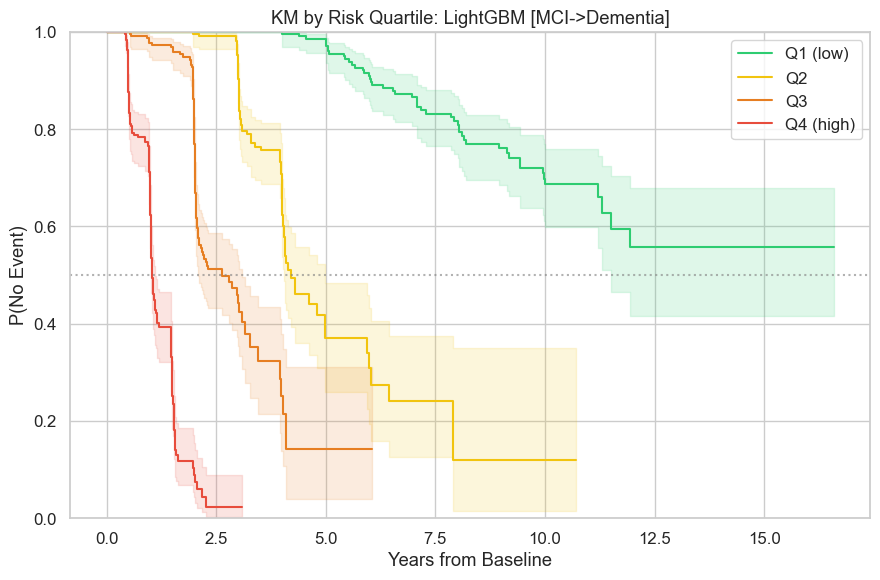

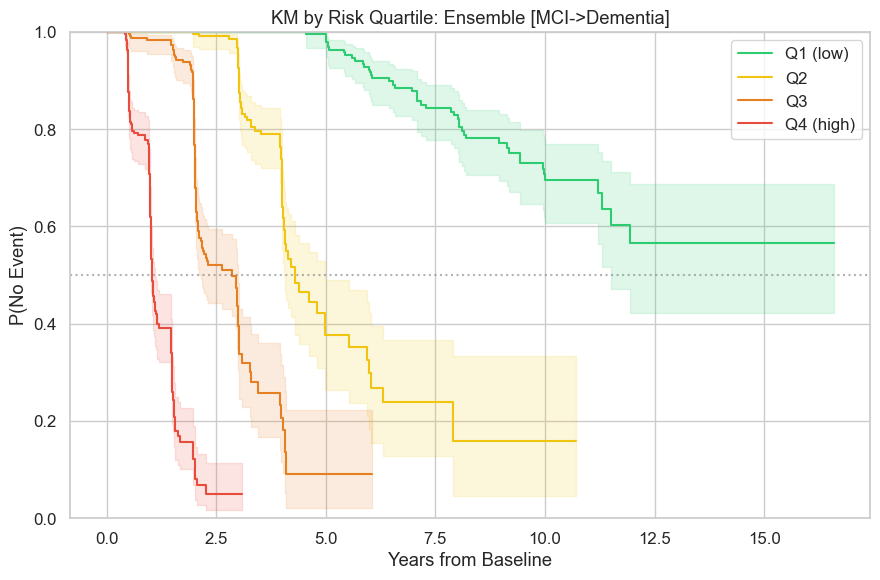

In [23]:
from postprocessing import km_risk_quartile

km_risk_quartile(lgb_scores_mci, y_ev_mci, y_dur_mci, 'LightGBM', 'MCI->Dementia')
km_risk_quartile(ens_scores_mci, y_ev_mci, y_dur_mci, 'Ensemble', 'MCI->Dementia')

## Cell 23 — Final Model Comparison Table
Summarize all model results in a ranked table.


FINAL MODEL COMPARISON TABLE
            Model        Cohort C-index  C-std
LightGBM Survival   CN->Decline  0.7659 0.0000
         DeepSurv   CN->Decline  0.7424 0.0000
Weighted Ensemble MCI->Dementia  0.9393 0.0000
  Domain Ensemble MCI->Dementia  0.9393 0.0000
LightGBM Survival MCI->Dementia  0.8977 0.0000
         DeepSurv MCI->Dementia  0.8587 0.0000

Saved: C:\Users\Shichen\OneDrive\549\alzheimer-prediction\Baseline\outputs/model_comparison.csv


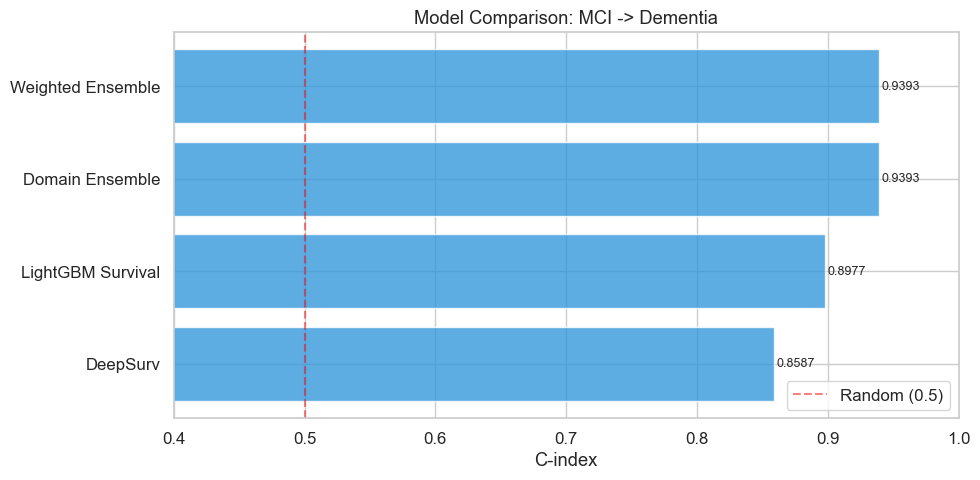

In [24]:
import warnings

rows = []
for (model, cohort), metrics in results.items():
    row = {
        'Model':  model,
        'Cohort': cohort,
        'C-index': f"{metrics[0]:.4f}",
        'C-std':   f"{metrics[1]:.4f}",
    }
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values(['Cohort','C-index'], ascending=[True,False])
print('\n' + '='*80)
print('FINAL MODEL COMPARISON TABLE')
print('='*80)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv(OUT_DIR / 'model_comparison.csv', index=False)
print(f'\nSaved: {OUT_DIR}/model_comparison.csv')

# Visual comparison bar chart
mci_res = results_df[results_df['Cohort'].str.contains('MCI')].copy()
mci_res['c_float'] = mci_res['C-index'].astype(float)
mci_res = mci_res.sort_values('c_float')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mci_res['Model'], mci_res['c_float'],
               color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set(xlabel='C-index', title='Model Comparison: MCI -> Dementia',
       xlim=(0.4, 1.0))
for bar, val in zip(bars, mci_res['c_float']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 24 — Subject × Time Matrix Construction
Build an aligned longitudinal matrix for future use by RNN / Transformer models.
Saves to disk as a NumPy tensor: (n_subjects, n_timepoints, n_features)

In [25]:
from postprocessing import build_subject_time_matrix

# Canonical time grid (in years from baseline)
TIME_GRID_YR = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0]
TIME_WINDOW  = 0.25   # ±3 months to assign a visit to a time slot

SEQ_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS13', 'LDELTOTAL', 'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain',
    'ABETA', 'TAU', 'PTAU', 'FDG',
]
SEQ_FEATURES = [f for f in SEQ_FEATURES if f in df.columns]



print(f'Building subject × time matrix for {len(rids_mci)} MCI subjects...')
tensor_mci, mask_mci = build_subject_time_matrix(
    df, rids_mci, TIME_GRID_YR, SEQ_FEATURES)
print(f'  MCI tensor shape: {tensor_mci.shape}')
print(f'  Mean visit coverage per time slot: {mask_mci.mean(axis=0).round(2)}')

np.save(OUT_DIR / 'mci_tensor.npy',    tensor_mci)
np.save(OUT_DIR / 'mci_mask.npy',      mask_mci)
np.save(OUT_DIR / 'mci_y_event.npy',   y_ev_mci)
np.save(OUT_DIR / 'mci_y_duration.npy',y_dur_mci)
print('Saved tensors to outputs/')

Building subject × time matrix for 958 MCI subjects...
  MCI tensor shape: (958, 12, 14)
  Mean visit coverage per time slot: [1.   0.81 0.92 0.69 0.74 0.61 0.4  0.25 0.18 0.12 0.06 0.02]
Saved tensors to outputs/
